# Synchronization Analysis With Recurrence Plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [ ]:
N = 3  
a, b, c = 0.2, 0.2, 5.7  
epsilon = 0.01  
T = 100  
dt = 0.1

A = np.ones((N, N)) - np.eye(N) 

def rossler_coupled(t, X):
    """
    X is a flattened vector [x1, y1, z1, x2, y2, z2, ..., xN, yN, zN]
    """
    X = X.reshape(N, 3)
    dX = np.zeros_like(X)
    
    for i in range(N):
        xi, yi, zi = X[i]
        dx = -yi - zi
        dy = xi + a*yi
        dz = b + zi*(xi - c)
        
        coupling_term = epsilon * np.sum(A[i] * (X[:,0] - xi))
        dx += coupling_term
        
        dX[i] = [dx, dy, dz]
    
    return dX.flatten()

np.random.seed(42)
X0 = np.random.rand(N*3)

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sol = solve_ivp(rossler_coupled, t_span, X0, t_eval=t_eval, method='RK45')

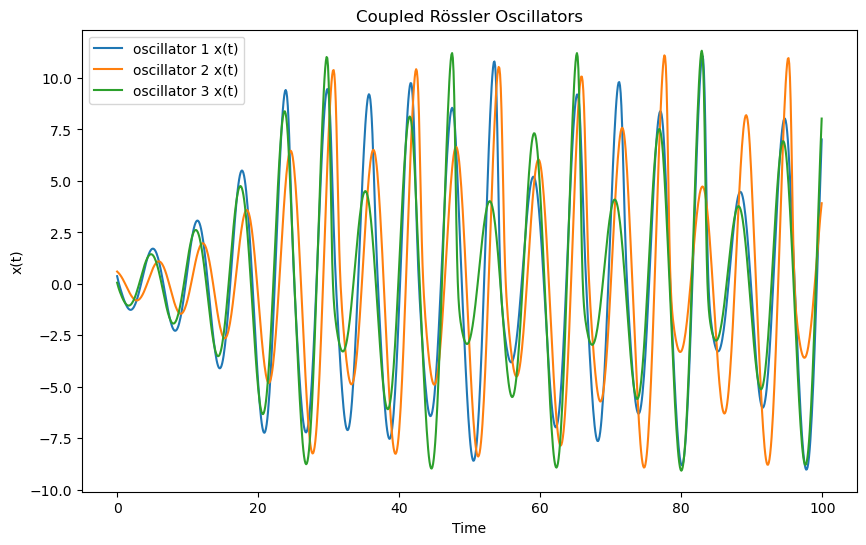

In [ ]:
plt.figure(figsize=(10,6))
for i in range(N):
    plt.plot(sol.t, sol.y[i*3], label=f'oscillator {i+1} x(t)')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Coupled Rössler Oscillators')
plt.legend()
plt.show()

# Recurrence Analysis

In [2]:
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot

In [ ]:
R = RecurrencePlot(sol.y[0], dim=3, tau=2, recurrence_rate=0.05)


Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


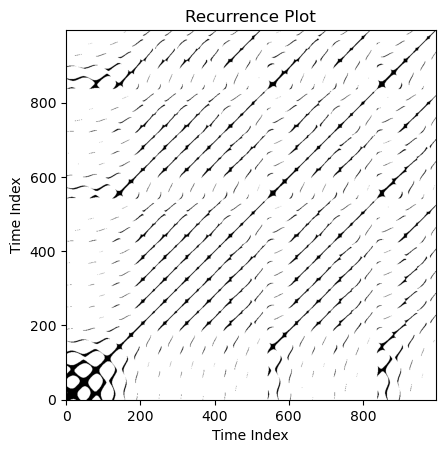

In [ ]:
Rmat = R.recurrence_matrix()

plt.imshow(Rmat, origin='lower', cmap='binary')
plt.title('Recurrence Plot')
plt.xlabel('Time Index')
plt.ylabel('Time Index')
plt.show()

In [3]:
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [ ]:
R_C = CrossRecurrencePlot(sol.y[0], sol.y[3], dim=3, tau=2, recurrence_rate=0.05)
R_J = JointRecurrencePlot(sol.y[0], sol.y[3], dim=(3,5), tau=(2,1),
    recurrence_rate=(0.05,0.04))

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating the supremum distance matrix...


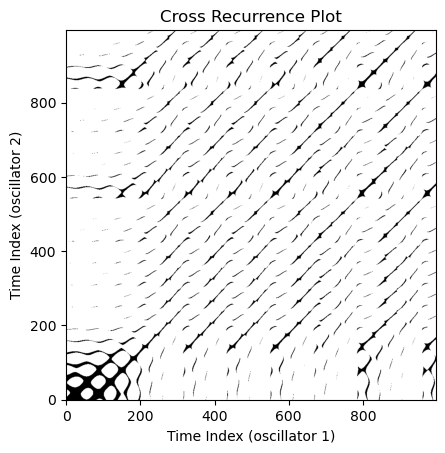

In [ ]:
RMat_C = R_C.recurrence_matrix()

plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

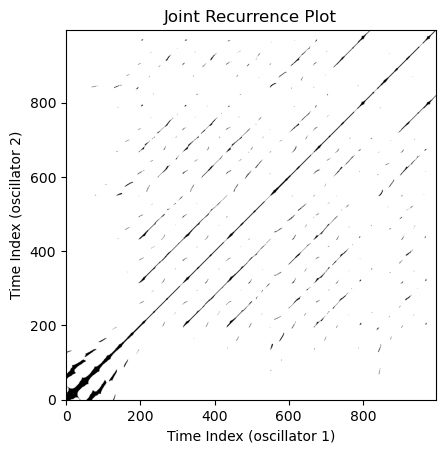

In [ ]:
RMat_J = R_J.recurrence_matrix()

plt.imshow(RMat_J, origin='lower', cmap='binary')
plt.title('Joint Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

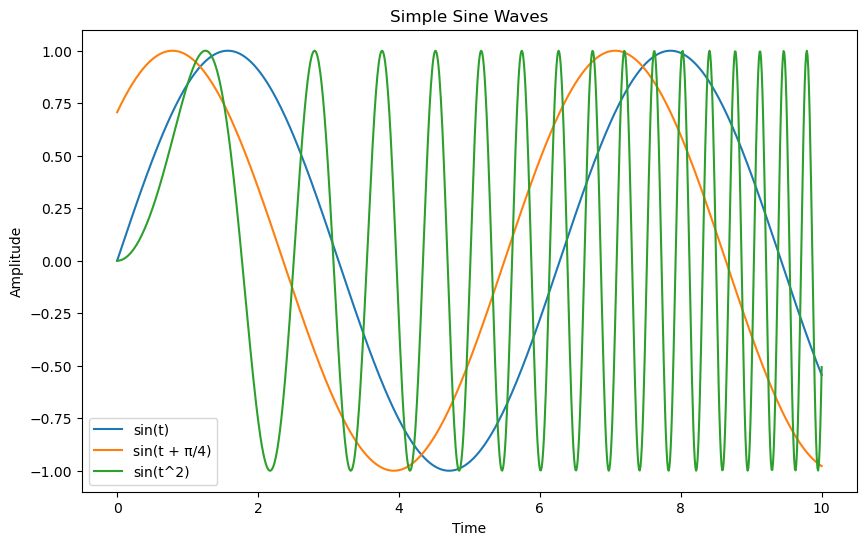

In [ ]:
### Simple Sine Wave Example

t = np.linspace(0, 10, 1000)

y1 = np.sin(t)
y2 = np.sin(t + np.pi/4)  # phase-shifted sine wave
y3 = np.sin(t**2)

plt.figure(figsize=(10,6))
plt.plot(t, y1, label='sin(t)')
plt.plot(t, y2, label='sin(t + π/4)')
plt.plot(t, y3, label='sin(t^2)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Simple Sine Waves')
plt.legend()
plt.show()

In [ ]:
R_C = CrossRecurrencePlot(y1, y3, dim=3, tau=2, recurrence_rate=0.05)

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


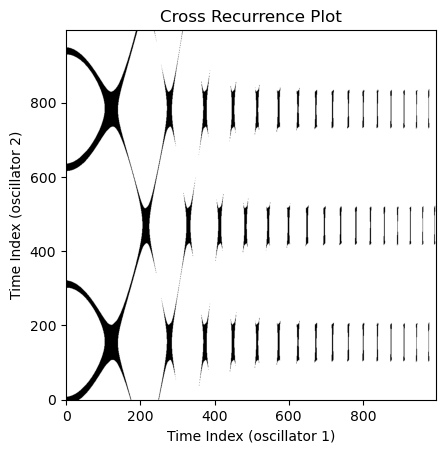

In [ ]:
RMat_C = R_C.recurrence_matrix()


plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

### Simple Kuramoto Model

$
\frac{d\theta_i}{dt} = \omega_i + \frac{1}{N} \Sigma_{j=1}^N K_{ij} sin(\theta_j - \theta_i)
$

In [4]:
def kuramoto(t, theta, omega, K):
    """
    theta : (N,) phase vector
    omega : (N,) natural frequencies
    K     : (N,N) coupling matrix
    """
    N = len(theta)
    diff = theta[None, :] - theta[:, None]
    coupling = np.sum(K * np.sin(diff), axis=1) / N
    return omega + coupling 

In [76]:
N = 10
T = 100.0
steps = 1000
t_eval = np.linspace(0, T, steps)

np.random.seed(0)

omega = np.random.normal(0, 1, N)          
K = np.zeros((N, N))
K = K + 2.2
np.fill_diagonal(K, 0)                     

theta0 = np.random.uniform(0, 2*np.pi, N)  

In [77]:
sol = solve_ivp(
    fun=lambda t, y: kuramoto(t, y, omega, K),
    t_span=(0, T),
    y0=theta0,
    t_eval=t_eval,
    method="RK45"
)

theta = sol.y 

In [78]:
x = np.cos(theta)
y = np.sin(theta)

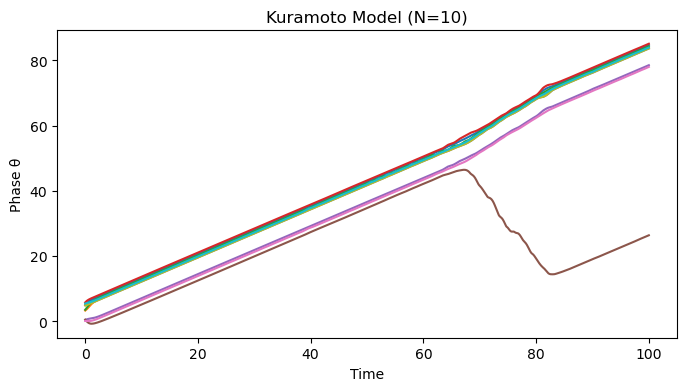

In [79]:
plt.figure(figsize=(8,4))
for i in range(N):
    plt.plot(t_eval, theta[i], label=f"osc {i+1}")

plt.xlabel("Time")
plt.ylabel("Phase θ")
plt.title("Kuramoto Model (N=10)")
plt.show()

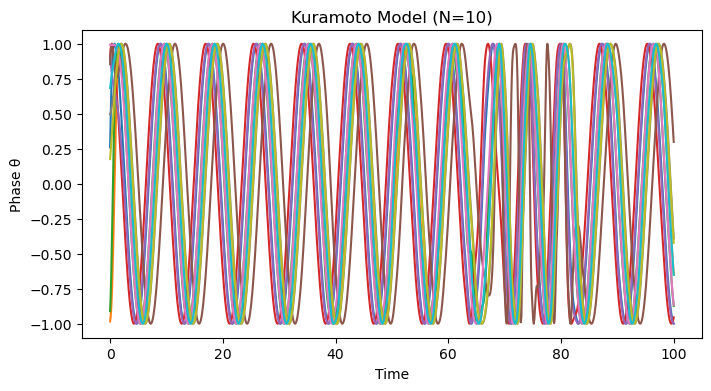

In [80]:
plt.figure(figsize=(8,4))
for i in range(N):
    plt.plot(t_eval, x[i], label=f"osc {i+1}")

plt.xlabel("Time")
plt.ylabel("Phase θ")
plt.title("Kuramoto Model (N=10)")
plt.show()

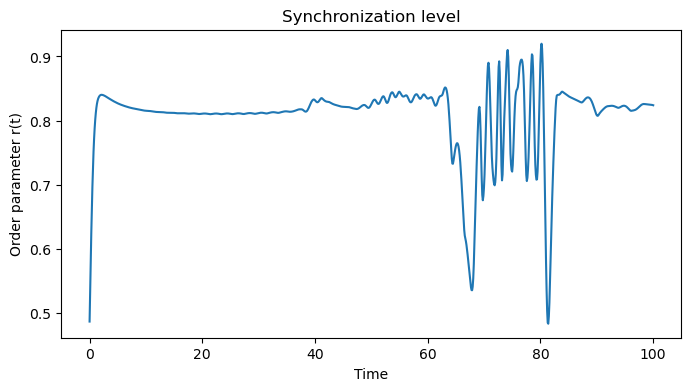

In [81]:
r = np.abs(np.mean(np.exp(1j*theta), axis=0))

plt.figure(figsize=(8,4))
plt.plot(t_eval, r)
plt.xlabel("Time")
plt.ylabel("Order parameter r(t)")
plt.title("Synchronization level")
plt.show()

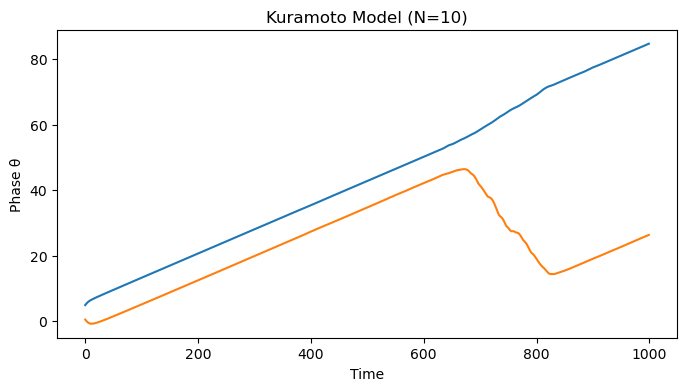

In [88]:
t1 = theta[0]
t2 = theta[5]

plt.figure(figsize=(8,4))
plt.plot(t1)
plt.plot(t2)

plt.xlabel("Time")
plt.ylabel("Phase θ")
plt.title("Kuramoto Model (N=10)")
plt.show()

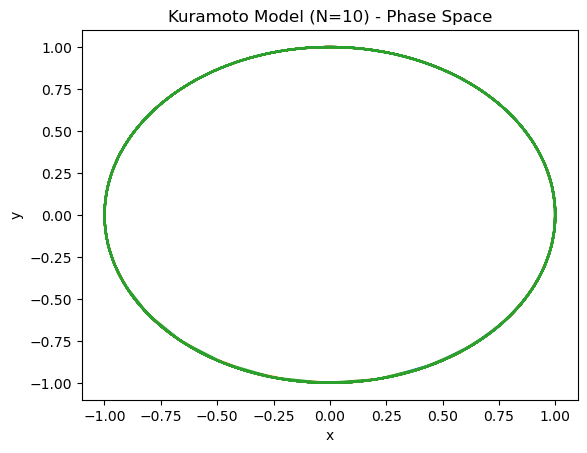

In [89]:
for i in range(3):
    plt.plot(x[i], y[i], label=f"osc {i+1}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Kuramoto Model (N=10) - Phase Space")
plt.show()

Calculating cross recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


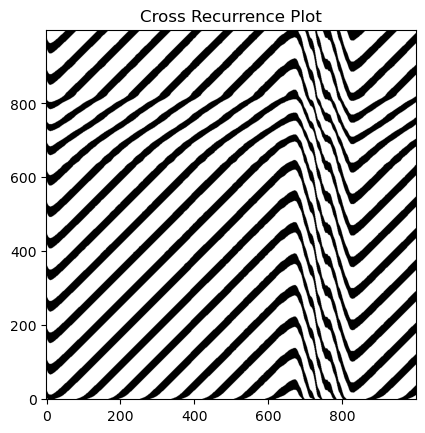

In [91]:
R_C = CrossRecurrencePlot(np.column_stack((x[0, :], y[0, :])), np.column_stack((x[5, :], y[5, :])), threshold=1, metric="euclidean")

RMat_C = R_C.recurrence_matrix()

plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.show()